### EX: Multi-Target Regression

In this lab, we will step up from `scikit-learn` and build a deep learning model using **TensorFlow/Keras**. Keras allows us to explicitly stack layers and track the learning process over multiple training cycles (epochs).

* **Generate Data:** Simulate altitude, throttle, and drag data to predict fuel consumption and time-on-target.

* **Scale Inputs AND Targets:** We must scale the inputs so large numbers do not overwhelm the network. **Crucially**, because Fuel is measured in the thousands and Time is measured in the hundreds, we must also scale the *targets*. If we don't, the network will focus entirely on minimizing the massive Fuel errors and completely ignore the Time predictions.

* **Build Architecture:** Deploy a Keras `Sequential` model with two hidden layers (64 neurons each, ReLU activation) and a final output layer of 2 neurons (Linear activation).

* **Compile & Train:** Compile the model using the Adam optimizer and Mean Squared Error (MSE) loss function.

* **Inverse Transform & Evaluate:** Convert the scaled predictions back into their original physical units, then plot them.


In [ ]:
#Only run this cell after selecting your kernel
!python.exe -m pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas tensorflow

/Users/mtodd/CS471/471Book/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,546 (17.76 KB)

 Trainable params: 4,546 (17.76 KB)

 Non-trainable params: 0 (0.00 B)

Training Keras model over 100 epochs...
Training complete.
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


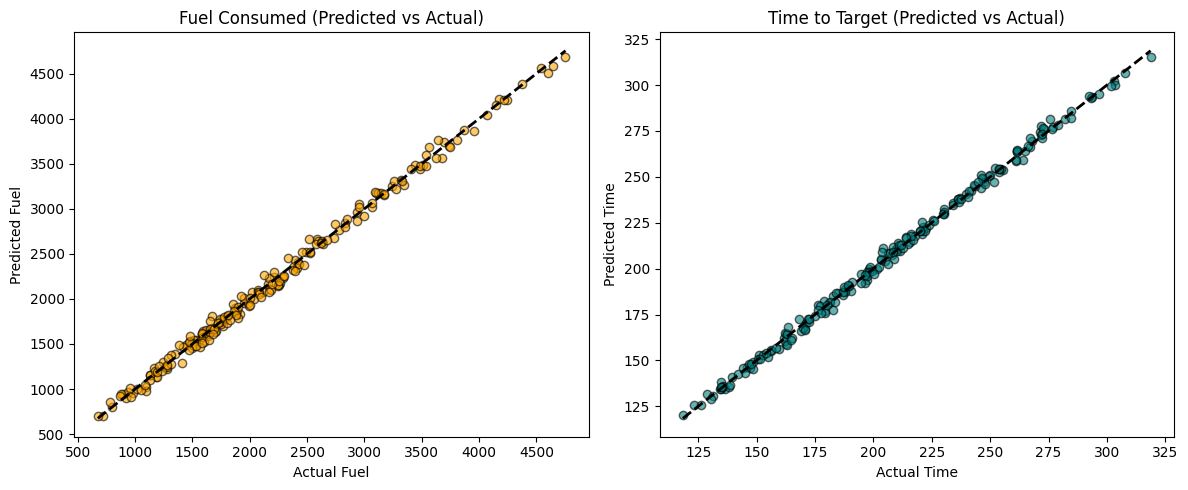

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Generate Flight Dynamics Data
np.random.seed(42)
n_flights = 1000
altitude = np.random.uniform(10000, 40000, n_flights)
throttle = np.random.uniform(50, 100, n_flights)
drag_coeff = np.random.uniform(0.02, 0.05, n_flights)

X_flight = np.column_stack((altitude, throttle, drag_coeff))

# Complex formulas for the targets
fuel_consumed = (throttle ** 1.5) * (drag_coeff * 100) - (altitude * 0.001) + np.random.normal(0, 50, n_flights)
time_to_target = 6000 / (throttle * (1 - drag_coeff)) + (altitude * 0.005) + np.random.normal(0, 2, n_flights)

Y_flight = np.column_stack((fuel_consumed, time_to_target))

# Split Data
X_tr, X_te, Y_tr, Y_te = train_test_split(X_flight, Y_flight, test_size=0.2, random_state=42)

# 2. Scale Features (X) AND Targets (Y)
scaler_X = StandardScaler()
X_tr_scaled = scaler_X.fit_transform(X_tr)
X_te_scaled = scaler_X.transform(X_te)

scaler_Y = StandardScaler()
Y_tr_scaled = scaler_Y.fit_transform(Y_tr)
# We do not transform Y_te here because we want to evaluate against the raw, real-world numbers later

# 3. Build the Keras Multi-Output Neural Network
model = Sequential([
    Dense(64, activation='relu', input_shape=(3,)), # Hidden Layer 1 (receives 3 inputs)
    Dense(64, activation='relu'),                   # Hidden Layer 2
    Dense(2, activation='linear')                   # Output Layer (2 values: Fuel and Time)
])

# Print the model output/summary
model.summary()


# Compile the model
model.compile(optimizer='adam', loss='mse')

# 4. Train the Model on the SCALED targets
print("Training Keras model over 100 epochs...")
history = model.fit(X_tr_scaled, Y_tr_scaled, epochs=100, validation_split=0.2, verbose=0)
print("Training complete.")

# 5. Predict and Inverse Transform
Y_pred_scaled = model.predict(X_te_scaled)
# Convert the scaled predictions (-1 to 1) back into real-world units (Gallons and Minutes)
Y_pred_real = scaler_Y.inverse_transform(Y_pred_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Fuel Prediction
axes[0].scatter(Y_te[:, 0], Y_pred_real[:, 0], alpha=0.6, color='orange', edgecolor='k')
axes[0].plot([Y_te[:,0].min(), Y_te[:,0].max()], [Y_te[:,0].min(), Y_te[:,0].max()], 'k--', lw=2)
axes[0].set_title('Fuel Consumed (Predicted vs Actual)')
axes[0].set_xlabel('Actual Fuel')
axes[0].set_ylabel('Predicted Fuel')

# Plot Time Prediction
axes[1].scatter(Y_te[:, 1], Y_pred_real[:, 1], alpha=0.6, color='teal', edgecolor='k')
axes[1].plot([Y_te[:,1].min(), Y_te[:,1].max()], [Y_te[:,1].min(), Y_te[:,1].max()], 'k--', lw=2)
axes[1].set_title('Time to Target (Predicted vs Actual)')
axes[1].set_xlabel('Actual Time')
axes[1].set_ylabel('Predicted Time')

plt.tight_layout()
plt.show()


### Interpreting the Results

Look at the plots. The dotted black line represents perfect predictions. The tight clustering of the orange and teal dots along the line proves that the network successfully learned to predict two highly distinct physical phenomena simultaneously.

By building the architecture explicitly in Keras, we can see exactly how the data flows. The `Dense(2)` output layer is the key. The network learns an internal representation of "aerodynamics" in its shared 64-neuron hidden layers. It figures out how throttle and drag interact geometrically, and then branches that shared knowledge out to the two specific output neurons.

Furthermore, this lab highlights a critical engineering constraint: **Target Scaling**. Had we not used `StandardScaler` on the $Y$ targets, the network's optimizer would have ignored the smaller time values to focus entirely on minimizing the larger fuel errors. By normalizing the data, we forced the network to treat a 10% error in time as equally important to a 10% error in fuel.
